<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB38b · Energía, trabajo y potencia

**Parte 5 · La física del cuerpo — Lección intermedia (entre el NB38 y el NB39)**

> En el NB37 aprendiste a describir el movimiento con **fuerzas** y **pares**: qué empuja, cuánto acelera. Hoy aprenderás otra forma de mirar exactamente la misma física, que a menudo es **mucho más rápida**: la **energía**.

¿Por qué hace falta otra forma? Por tres razones muy prácticas:

1. **Responde preguntas sin simular.** ¿A qué velocidad llega al suelo el palo de escoba del NB37? Con fuerzas, hay que simular pasito a pasito. Con energía, es **una línea** de cuentas.
2. **Detecta errores.** La energía total de un sistema sin rozamiento **no cambia nunca**. Si en una simulación sube sola, la simulación está mal. En el NB45 y el NB49 la usarás exactamente para eso.
3. **Los robots tienen batería.** Un robot que anda muy bien pero gasta la batería en diez minutos no sirve. ¿Cuánto gasta un motor? ¿Por qué se calienta aunque esté quieto? ¿Por qué Gymnasium castiga las acciones grandes (NB35)? La respuesta es la **potencia**.

Las palabras de hoy (**trabajo**, **energía**, **potencia**) las usas a diario con otros significados. En física cada una tiene un significado **exacto**, con su número y su unidad. Vamos a construirlas una a una.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

g = 9.81          # la gravedad, en m/s² (NB37)

## 1 · El trabajo: fuerza por distancia

### La idea

Subir una mochila de 10 kg una planta (3 m) cansa. Subirla **dos** plantas cansa el doble. Subir **dos** mochilas una planta, también el doble. El "esfuerzo" depende de **cuánta fuerza** haces y de **cuánta distancia** la haces. En física, a ese producto se le llama **trabajo**:

```
   trabajo  =  fuerza  ×  distancia
```

Su unidad es newton por metro, N·m, que tiene nombre propio: el **julio** (J), en honor al físico inglés James Joule. **1 julio** es el trabajo de empujar con 1 newton a lo largo de 1 metro: más o menos, levantar una manzana pequeña (100 g, que pesa 0,98 N) un metro.

Para subir la mochila hay que hacer, como poco, una fuerza igual a su peso, m·g (NB37):


In [2]:
masa_mochila = 10
peso = masa_mochila * g                       # la fuerza para sostenerla (N)
trabajo = peso * 3                            # a lo largo de 3 metros
print(f"peso: {peso:.1f} N  →  trabajo: {trabajo:.0f} J")

peso: 98.1 N  →  trabajo: 294 J


**294 julios** para subir la mochila una planta.

### Solo cuenta la parte de la fuerza que va en la dirección del movimiento

Ahora lleva la mochila en brazos **por un pasillo llano**, 10 metros. Te cansas (los músculos trabajan para sostenerla), pero en física el trabajo sobre la mochila es **cero**: la fuerza (hacia arriba) y el movimiento (horizontal) son **perpendiculares**. Sostenerla hacia arriba no la hace avanzar ni subir.

Y si empujas un carrito con la fuerza un poco inclinada hacia abajo (como un carrito de la compra), solo la parte de la fuerza que va **hacia delante** hace trabajo; la parte que aprieta contra el suelo, no.

¿Te suena "la parte de un vector que va en la dirección de otro"? Es el **producto escalar** del NB13. El trabajo, en general, es:

```
   trabajo  =  fuerza · desplazamiento         (producto escalar de los dos vectores)
```

Si van en la misma dirección, es fuerza × distancia; si son perpendiculares, 0; si van en sentidos **contrarios** (frenar algo que se mueve), el trabajo es **negativo**: le **quitas** energía.


In [3]:
fuerza = np.array([30.0, -20.0])           # 30 N hacia delante, 20 N hacia abajo (contra el suelo)
desplazamiento = np.array([5.0, 0.0])      # el carrito avanza 5 m en horizontal
print("trabajo:", np.dot(fuerza, desplazamiento), "J")

trabajo: 150.0 J


**150 J** = 30 N × 5 m. Los 20 N hacia abajo no cuentan.

### El trabajo de un giro

Para los giros, lo mismo cambiando fuerza por **par** (NB37) y distancia por **ángulo** (en radianes, NB36):

```
   trabajo de un giro  =  par  ×  ángulo girado (en radianes)
```

Un motor que hace 2 N·m mientras gira media vuelta (π radianes) hace 2 × π ≈ 6,3 J de trabajo. (¿Por qué funciona? Un par es fuerza por brazo, y girar un ángulo θ con un brazo r recorre un arco de r·θ metros, NB36. Fuerza × arco = fuerza × r × θ = par × θ.)

Ojo con las unidades: el par se mide en N·m, y el julio también es N·m. No son lo mismo, aunque se escriban igual. Por eso, para el trabajo, se usa siempre la palabra **julio**.


## 2 · La energía de movimiento: ½·m·v²

### ¿Adónde va el trabajo?

Si empujas un carrito en un suelo **sin rozamiento**, el trabajo que haces no "desaparece": el carrito **acelera**. Todo el trabajo se queda guardado en su **movimiento**. A esa energía guardada se le llama **energía cinética** ("cinética" viene del griego *kinesis*, movimiento).

¿Cuánta? Hagamos el experimento con la cadena de oro del NB07: un carrito de 2 kg, parado, empujado con 10 N durante 3 segundos. En cada pasito sumamos el trabajo (fuerza × lo que avanza en ese pasito):


In [4]:
masa, fuerza, paso = 2.0, 10.0, 0.001
velocidad, posicion, trabajo = 0.0, 0.0, 0.0
for i in range(3000):                               # 3000 pasitos de 1 ms = 3 s
    velocidad = velocidad + (fuerza / masa) * paso  # Newton: a = F / m (NB37)
    avance = velocidad * paso
    posicion = posicion + avance
    trabajo = trabajo + fuerza * avance             # el trabajo de este pasito
print(f"velocidad final: {velocidad:.2f} m/s | trabajo total: {trabajo:.1f} J")

velocidad final: 15.00 m/s | trabajo total: 225.1 J


El carrito acaba a 15 m/s, y le hemos hecho unos 225 J de trabajo. ¿Hay una fórmula que dé 225 a partir de la masa (2) y la velocidad (15)? Prueba: 2 × 15 = 30, no. 2 × 15² = 450, el doble. **½ × 2 × 15² = 225**. ¡Esa!

```
   energía cinética  =  ½ · m · v²
```

### Por qué ½·m·v²

No es casualidad, y la cuenta es corta. Empujando con una fuerza F constante desde parado (NB37, NB04b):

- La aceleración es a = F/m, así que **F = m·a**.
- Tras un tiempo t, la velocidad es **v = a·t**.
- Y la distancia recorrida es **d = ½·a·t²** (la de la caída libre del NB04b, con a en vez de g).

El trabajo es F × d = m·a × ½·a·t² = ½·m·(a·t)², y como a·t = v: **trabajo = ½·m·v²**. Todo el trabajo se ha convertido en ½·m·v².

### Lo que dice la fórmula

- **El doble de masa, el doble de energía**: normal.
- **El doble de velocidad, cuatro veces más energía** (por el cuadrado). Por eso un coche a 100 km/h choca **cuatro** veces más fuerte que a 50, y necesita cuatro veces más distancia para frenar.
- La energía cinética **nunca es negativa** (un cuadrado nunca lo es): da igual hacia dónde te muevas.

### Para los giros: ½·I·ω²

Algo que **gira** también guarda energía (una peonza, un volante de inercia). La fórmula es la gemela, cambiando masa por **inercia de giro** I y velocidad por **velocidad de giro** ω (NB37):

```
   energía cinética de giro  =  ½ · I · ω²
```

La necesitarás en el NB50, para entender por qué un motor con reductora "parece" mucho más pesado de lo que es.


## 3 · La energía de altura: m·g·h

Sube la mochila a la estantería. Has hecho 294 J de trabajo, pero la mochila está **quieta**: no tiene energía cinética. ¿Se han perdido?

No: están **guardados en la altura**. Si la mochila se cae de la estantería, llegará al suelo con velocidad: recupera el trabajo como movimiento. A esta energía "en espera" se le llama **energía potencial** (de la gravedad):

```
   energía potencial  =  m · g · h          (h = la altura, en metros)
```

Es exactamente el trabajo de subirla: peso (m·g) × altura (h).

Un detalle: ¿altura medida **desde dónde**? Desde donde tú quieras (el suelo, la mesa, el centro de la Tierra). Lo que importa nunca es la energía potencial en sí, sino **cuánto cambia**, y los cambios no dependen de dónde pongas el cero. Es como medir alturas desde el nivel del mar o desde tu calle: los edificios miden lo mismo.

Para un robot, la h es la altura de su **centro de masas** (NB38): en la energía potencial, todo el robot cuenta como si estuviera en ese punto. En el NB45 verás que MuJoCo calcula 181 J para un robot de 23,6 kg con el CdM a 0,78 m de altura: 23,6 × 9,81 × 0,783 ≈ 181.


## 4 · La conservación de la energía

### La ley

Juntamos las dos: a la suma de cinética y potencial se le llama **energía mecánica**. Y la ley más famosa de la física dice:

> **Si no hay rozamientos ni motores, la energía mecánica total no cambia nunca.** Puede pasar de potencial a cinética y al revés, pero la suma es siempre la misma.

Es la **conservación de la energía**. Comprobémosla con una pelota de 0,5 kg que cae desde 0,75 m (la del NB02), simulada a pasitos:


In [5]:
m, altura, v, paso = 0.5, 0.75, 0.0, 0.0001
for i in range(3):                                   # tres "fotos" de la caída
    print(f"h = {altura:.3f} m | cinética {0.5 * m * v ** 2:.4f} J + potencial {m * g * altura:.4f} J "
          f"= {0.5 * m * v ** 2 + m * g * altura:.4f} J")
    for j in range(1300):                            # 0,13 s de caída entre foto y foto
        v = v - g * paso                             # la gravedad acelera hacia abajo
        altura = altura + v * paso

h = 0.750 m | cinética 0.0000 J + potencial 3.6787 J = 3.6787 J
h = 0.667 m | cinética 0.4066 J + potencial 3.2718 J = 3.6784 J
h = 0.418 m | cinética 1.6264 J + potencial 2.0517 J = 3.6781 J


La potencial baja, la cinética sube, y la **suma** se queda en 3,678 J (moviéndose solo en la cuarta cifra decimal: el error de los pasitos, NB07).

### La pregunta sin simular

Ahora el truco. ¿A qué velocidad llega la pelota al suelo? Toda la potencial del principio se ha convertido en cinética:

```
   ½ · m · v²  =  m · g · h           →  la m se va a los dos lados  →        v = √(2 · g · h)
```

(Despejar, NB04b: dividir entre m, multiplicar por 2, raíz cuadrada.) Sin simular nada:


In [6]:
print(f"velocidad al llegar al suelo: {math.sqrt(2 * g * 0.75):.2f} m/s")

velocidad al llegar al suelo: 3.84 m/s


**3,84 m/s** (unos 14 km/h). Fíjate: la **masa ha desaparecido** otra vez, como en el NB37. Una pelota de hierro y una de goma llegan igual de deprisa (sin aire). Y la respuesta no depende del **camino**: si la pelota bajara 0,75 m rodando por una rampa sin rozamiento, también llegaría a 3,84 m/s (más tarde, pero igual de rápida). Las fuerzas te obligan a seguir el camino paso a paso; la energía solo mira el **principio y el final**.


## 5 · El palo de escoba, con energía

### La pregunta

En el NB37 simulaste el palo de escoba de 1,5 m y 1 kg cayendo desde 0,05 radianes hasta el suelo. ¿A qué **velocidad de giro** llega al suelo? Con energía, sin simular:

- **Potencial**: el CdM del palo está en su mitad. Con el palo inclinado θ desde la vertical, el CdM está a una altura (L/2)·cos θ (la "sombra vertical" del NB36). Al caer de θ₀ = 0,05 a θ = π/2 (horizontal, cos = 0), la altura del CdM baja de (L/2)·cos 0,05 a 0.
- **Cinética**: el palo gira alrededor de su extremo, así que su energía cinética es de giro, ½·I·ω², con I = m·L²/3 (NB37).

Igualando lo que se pierde de potencial con lo que se gana de cinética:

```
   ½ · (m·L²/3) · ω²  =  m · g · (L/2) · cos θ₀            →       ω = √(3 · g · cos θ₀ / L)
```

(La m se va otra vez; el resto es despejar. Inténtalo tú en el ejercicio E5.)


In [7]:
L, masa_palo, theta0 = 1.5, 1.0, 0.05
omega_energia = math.sqrt(3 * g * math.cos(theta0) / L)
print(f"velocidad de giro al llegar al suelo (con energía): {omega_energia:.3f} rad/s")

velocidad de giro al llegar al suelo (con energía): 4.427 rad/s


Unos **4,43 rad/s**. Ahora, la comprobación: la simulación del NB37 (la misma cadena de oro), devolviendo la velocidad final en lugar de los tiempos:

In [8]:
def caida(largo, theta_inicial=0.05, paso=0.0001):
    theta, velocidad = theta_inicial, 0.0
    while theta < math.pi / 2:
        aceleracion = 3 * g / (2 * largo) * math.sin(theta)   # la ecuación de la escoba (NB37)
        velocidad = velocidad + aceleracion * paso
        theta = theta + velocidad * paso
    return velocidad

print(f"velocidad de giro al llegar al suelo (simulando):   {caida(L):.3f} rad/s")

velocidad de giro al llegar al suelo (simulando):   4.427 rad/s


¡La misma, hasta la tercera cifra decimal! Y una vez más, el palo de hierro y el de madera, iguales.

### El examen de MuJoCo

El mismo palo del NB37 en MuJoCo. Esta vez, a cada paso calculamos **nosotros** su energía mecánica, con lo que MuJoCo nos da: el ángulo (`qpos`) y la velocidad de giro (`qvel`, NB36). Si MuJoCo hace bien la física, la suma no debería moverse:


In [9]:
import mujoco

plano = '''
<mujoco>
  <option timestep="0.001"/>
  <worldbody>
    <body>
      <joint type="hinge" axis="0 1 0"/>
      <geom type="cylinder" fromto="0 0 0  0 0 1.5" size="0.005" mass="1"/>
    </body>
  </worldbody>
</mujoco>
'''
modelo = mujoco.MjModel.from_xml_string(plano)
datos = mujoco.MjData(modelo)
I = masa_palo * L ** 2 / 3                                  # inercia de giro sobre el extremo (NB37)

(El mismo plano del NB37: un palo de 1,5 m y 1 kg con una bisagra en su extremo de abajo.) Una función para la energía, y la caída:

In [10]:
def energia(theta, omega):
    cinetica = 0.5 * I * omega ** 2
    potencial = masa_palo * g * (L / 2) * math.cos(theta)
    return cinetica, potencial

datos.qpos[0] = theta0
while datos.qpos[0] < math.pi / 2:
    if round(datos.time, 3) in (0.0, 0.8, 1.2):        # tres "fotos"
        c, p = energia(datos.qpos[0], datos.qvel[0])
        print(f"t = {datos.time:.1f} s | cinética {c:.3f} + potencial {p:.3f} = {c + p:.3f} J")
    mujoco.mj_step(modelo, datos)
print(f"MuJoCo llega al suelo a {datos.qvel[0]:.3f} rad/s (con energía: {omega_energia:.3f})")

t = 0.0 s | cinética 0.000 + potencial 7.348 = 7.348 J
t = 0.8 s | cinética 0.336 + potencial 7.011 = 7.347 J
t = 1.2 s | cinética 3.671 + potencial 3.667 = 7.338 J
MuJoCo llega al suelo a 4.426 rad/s (con energía: 4.427)


(`datos.time` es el reloj de la simulación; `round(..., 3)` lo redondea a milésimas para poder compararlo con 0,8 sin líos de decimales, NB05b.)

La energía total se queda en **7,35 J** mientras pasa de potencial a cinética (al final, 7,34: una centésima menos, el error de los pasitos de 1 ms). Y la velocidad final casa con la de nuestra cuenta de una línea. Ya tienes una herramienta para **comprobar** cualquier simulador: si la energía de algo sin rozamiento ni motores no se conserva, algo va mal.


## 6 · Cuando la energía "se pierde": la disipación

En el mundo real, una pelota que bota no vuelve a la misma altura, y un columpio acaba parándose. ¿Se ha roto la ley?

No. La energía mecánica se convierte en **otras formas de energía** que no vemos: **calor** (frota tus manos: se calientan), **sonido** (el "plof" de la pelota), deformación. La energía total del universo se conserva siempre; la **mecánica** solo se conserva cuando no hay nada que la convierta en calor. A esa pérdida se le llama **disipación**, y las cosas que disipan energía son:

- el **rozamiento** (los pies que resbalan, los engranajes de los motores, NB40);
- los **amortiguadores** (como el de la Hopper-estatua del NB38: un amortiguador existe **para** disipar);
- los **choques**: en el NB45 verás una caja que cae y no rebota nada: toda su cinética se disipa en el contacto.

Con esto, la regla del detector de errores (NB45) queda completa:

- La energía mecánica **baja** un poco → normal: rozamientos, amortiguadores, choques (y algo de error de los pasitos).
- La energía mecánica **sube** sin que ningún motor ni empujón la meta → **la simulación está mal**.


## 7 · La potencia: lo deprisa que se hace el trabajo

### La idea

Subir la mochila una planta son 294 J, tanto si subes andando en un minuto como si subes corriendo en diez segundos. Pero corriendo te cansas mucho más. La diferencia es la **rapidez** con la que haces el trabajo, y se llama **potencia**:

```
   potencia  =  trabajo  ÷  tiempo
```

Su unidad es el julio por segundo, que tiene nombre propio: el **vatio** (W), en honor a James Watt, el de la máquina de vapor. Una bombilla LED gasta unos 10 W; un microondas, unos 1000 W (1 kW).


In [11]:
for tiempo in [60, 10]:
    print(f"subir la mochila en {tiempo:>2} s: {294 / tiempo:5.1f} W")

subir la mochila en 60 s:   4.9 W
subir la mochila en 10 s:  29.4 W


### Potencia = fuerza × velocidad

En un pasito muy corto, el trabajo es fuerza × lo que avanzas. Dividiendo entre el tiempo del pasito, "lo que avanzas ÷ tiempo" es la velocidad:

```
   potencia  =  fuerza × velocidad                (en un giro:   potencia  =  par × velocidad de giro)
```

La de los giros es **la fórmula de los motores**. Un motor de Hopper puede hacer 200 N·m (NB37). Si a la vez gira la rodilla a 10 rad/s (más o menos 1,6 vueltas por segundo), está dando:


In [12]:
par, omega = 200, 10
print(f"potencia del motor: {par * omega} W")

potencia del motor: 2000 W


**2000 W**: como dos microondas, en una sola rodilla. En el NB40 verás que ningún motor real puede dar a la vez su par máximo y su velocidad máxima, justo porque eso exigiría una potencia enorme.

### El signo de la potencia

- **Par y giro en el mismo sentido** (potencia **positiva**): el motor **da** energía. Levanta el robot, lo impulsa.
- **Par y giro en sentidos contrarios** (potencia **negativa**): el motor **frena** un movimiento: **absorbe** energía. Pasa al aterrizar de un salto, al bajar escaleras, al sentarse despacio. Esa energía, en casi todos los robots, se convierte en calor (algunos la recuperan para la batería, como los coches eléctricos al frenar).


## 8 · Por qué los motores gastan aunque no se muevan

Una pregunta con trampa: un robot quieto, con las rodillas dobladas, sosteniendo su peso. Sus motores hacen par, pero no giran: potencia mecánica = par × 0 = **0**. ¿Gasta batería?

**Sí, y bastante.** La potencia mecánica es lo que el motor **entrega**, no lo que **consume**. Un motor eléctrico hace par haciendo pasar **corriente** por sus bobinas, y el par es proporcional a la corriente (el doble de par, el doble de corriente). Pero cualquier corriente que pasa por un cable lo **calienta**, y ese calor crece con el **cuadrado** de la corriente (el doble de corriente, cuatro veces más calor). Así que:

```
   calor perdido en el motor  ∝  par²            (∝ significa "proporcional a")
```

Aunque el motor no se mueva, sostener un par cuesta energía, y la convierte toda en calor. Es lo que viste anunciado en el NB40... y lo que les pasa a tus músculos en una sentadilla quieta.

### El castigo de control de Gymnasium

Ahora entiendes la recompensa de Hopper del NB35: castiga **0,001 × (suma de las acciones al cuadrado)**. Las acciones son pares (normalizados), así que ese término es, más o menos, **el calor que generan los motores**: un castigo por gastar batería. Al cuadrado, porque así es la física: un par doble cuesta cuatro veces más. En el NB43 y el NB44 verás qué pasa cuando este término es demasiado pequeño: el robot "corre a lo loco" sin importarle el gasto.

### El coste de transporte

¿Cómo comparar lo eficiente que es andar para un robot de 30 kg y una persona de 70? No vale comparar julios: el pesado siempre gasta más. Los ingenieros usan el **coste de transporte**:

```
   coste de transporte  =  energía gastada  ÷  (peso × distancia recorrida)
```

Es la energía gastada **por cada newton de peso y cada metro**. No tiene unidades (J ÷ (N × m) = J ÷ J), así que se puede comparar entre cualquier cosa que se mueva. Según un estudio famoso de 2005 (Collins y colegas, en la revista *Science*), una persona andando tiene un coste de transporte de más o menos **0,2**, y el robot ASIMO de Honda, de unos **3,2**: **dieciséis veces más**. Andar de forma eficiente sigue siendo uno de los grandes retos de la robótica, y uno de los motivos por los que se entrenan robots con recompensas que castigan el gasto.


In [13]:
def coste_de_transporte(energia_J, masa_kg, distancia_m):
    return energia_J / (masa_kg * g * distancia_m)

# Una persona de 70 kg que anda 1 km gastando unos 140.000 J (unas 33 kilocalorías)
print(f"persona: {coste_de_transporte(140_000, 70, 1000):.2f}")

persona: 0.20


(La kilocaloría, la "caloría" de los envases de comida, son 4184 J.) Sale 0,2, como en el estudio.


## 9 · Resumen de la lección

1. **Trabajo** = fuerza × distancia (solo la parte en la dirección del movimiento: el **producto escalar** fuerza · desplazamiento). En giros, **par × ángulo** (radianes). Unidad: **julio** (J). Negativo si frenas.
2. **Energía cinética** = **½·m·v²** (el trabajo para ponerlo en marcha); de giro, **½·I·ω²**. El doble de velocidad, cuatro veces más energía.
3. **Energía potencial** = **m·g·h** (el trabajo para subirlo); para un robot, h = la altura del CdM. Solo importan sus cambios.
4. **Conservación**: sin rozamientos ni motores, cinética + potencial no cambia. Responde sin simular: **v = √(2·g·h)**; el palo de escoba llega al suelo a ω = √(3·g·cos θ₀ / L) ≈ 4,43 rad/s, como nuestra simulación y MuJoCo.
5. **Disipación**: rozamiento, amortiguadores y choques convierten energía mecánica en calor. Energía que **baja**, normal; que **sube** sola, **simulación mal**.
6. **Potencia** = trabajo ÷ tiempo = **fuerza × velocidad** = **par × ω**. Unidad: **vatio** (W). Positiva = el motor da energía; negativa = la absorbe (frena).
7. Un motor quieto que hace par **gasta**: calor ∝ par². Por eso el **castigo de control** usa acciones **al cuadrado**.
8. **Coste de transporte** = energía ÷ (peso × distancia): persona ≈ 0,2; ASIMO ≈ 3,2.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Trabajo** | Fuerza por distancia en la dirección del movimiento (o par por ángulo). |
| **Julio (J)** | La unidad de trabajo y de energía: 1 N a lo largo de 1 m. |
| **Energía cinética** | La energía del movimiento: ½·m·v² (de giro, ½·I·ω²). |
| **Energía potencial** | La energía guardada en la altura: m·g·h. |
| **Energía mecánica** | Cinética + potencial. |
| **Conservación de la energía** | Sin rozamientos ni motores, la energía mecánica no cambia. |
| **Disipación** | Convertir energía mecánica en calor (rozamiento, amortiguadores, choques). |
| **Potencia** | Lo deprisa que se hace un trabajo: fuerza × velocidad, par × ω. |
| **Vatio (W)** | La unidad de potencia: 1 julio cada segundo. |
| **Coste de transporte** | Energía gastada por cada newton de peso y cada metro recorrido. |


## 10 · Ejercicios

**E1.** Un robot de 30 kg sube una escalera de 2 m de altura. ¿Cuánto trabajo hace, como mínimo, contra la gravedad? Si tarda 8 s, ¿qué potencia media necesita?

**E2.** Una fuerza de 50 N tira de un trineo con la cuerda inclinada: el vector fuerza es (40, 30) (40 N hacia delante, 30 N hacia arriba). El trineo avanza 10 m en horizontal. ¿Cuánto trabajo hace la fuerza? ¿Y si el trineo avanzara 10 m **hacia atrás** (resbalando cuesta abajo)?

**E3.** Un coche de 1000 kg va a 50 km/h y otro igual a 100 km/h. Calcula sus energías cinéticas (¡pasa antes a m/s: divide entre 3,6!). ¿Cuántas veces más tiene el segundo?

**E4.** ¿Desde qué altura habría que soltar una pelota para que llegue al suelo a 10 m/s? (Despeja h de v = √(2·g·h).) Compruébalo simulando la caída a pasitos.

**E5.** Deduce ω = √(3·g·cos θ₀ / L) del apartado 5 a partir de ½·(m·L²/3)·ω² = m·g·(L/2)·cos θ₀. Luego: ¿a qué velocidad de giro llega al suelo un **lápiz** de 15 cm que cae desde la misma inclinación? ¿Y la **punta** del lápiz, en m/s? (Pista: la velocidad de un punto a distancia r del eje es r·ω, NB36.)

**E6.** Un motor hace un par de −15 N·m mientras la articulación gira a +4 rad/s. ¿Qué potencia tiene? ¿Está dando o absorbiendo energía? ¿Qué podría estar haciendo el robot?

**E7.** En una sentadilla quieta, la rodilla de un robot hace 40 N·m, y la de otro, 80 N·m. Si el calor es proporcional al par², ¿cuántas veces más se calienta el segundo motor? ¿Y si la acción de Hopper pasa de 0,5 a 1, cuántas veces crece el castigo de control?

**E8.** Un robot de 25 kg anda 100 m gastando 50.000 J de batería. ¿Cuál es su coste de transporte? ¿Más cerca de una persona o de ASIMO?

---

### Soluciones

<details>
<summary>▶ Solución E1</summary>

Trabajo = m·g·h = 30 × 9,81 × 2 ≈ **588,6 J**. Potencia media = 588,6 / 8 ≈ **73,6 W**.

```python
trabajo = 30 * g * 2
print(f"{trabajo:.1f} J, {trabajo / 8:.1f} W")
```
</details>

<details>
<summary>▶ Solución E2</summary>

Producto escalar: (40, 30) · (10, 0) = 400 + 0 = **400 J**. La parte vertical (30 N) no hace trabajo. Hacia atrás: (40, 30) · (−10, 0) = **−400 J**: la fuerza va contra el movimiento, le quita energía al trineo (lo frena).

```python
f = np.array([40.0, 30.0])
print(np.dot(f, np.array([10.0, 0.0])), np.dot(f, np.array([-10.0, 0.0])))
```
</details>

<details>
<summary>▶ Solución E3</summary>

50 km/h = 13,9 m/s → ½ × 1000 × 13,9² ≈ **96.451 J**. 100 km/h = 27,8 m/s → ≈ **385.802 J**. Exactamente **cuatro veces** más (el doble de velocidad, al cuadrado).

```python
for kmh in [50, 100]:
    v = kmh / 3.6
    print(f"{kmh} km/h: {0.5 * 1000 * v ** 2:,.0f} J")
```
</details>

<details>
<summary>▶ Solución E4</summary>

v² = 2·g·h → h = v² / (2·g) = 100 / 19,62 ≈ **5,10 m** (un segundo piso).

```python
h = 10 ** 2 / (2 * g)
altura, v, paso = h, 0.0, 0.0001
while altura > 0:
    v = v - g * paso
    altura = altura + v * paso
print(f"h = {h:.2f} m → llega a {abs(v):.2f} m/s")
```
</details>

<details>
<summary>▶ Solución E5</summary>

Tachamos m a los dos lados: ½·(L²/3)·ω² = g·(L/2)·cos θ₀. Multiplicamos por 2: (L²/3)·ω² = g·L·cos θ₀. Multiplicamos por 3 y dividimos entre L²: ω² = 3·g·cos θ₀ / L. Raíz: **ω = √(3·g·cos θ₀ / L)**.

Lápiz (L = 0,15): ω ≈ **14,0 rad/s** (√10 ≈ 3,16 veces más que la escoba, porque la L está dividiendo dentro de la raíz). La punta, a 0,15 m del eje: 0,15 × 14,0 ≈ **2,1 m/s**. La de la escoba: 1,5 × 4,43 ≈ 6,6 m/s. El lápiz gira más deprisa, pero su punta va más despacio.

```python
for nombre, largo in [("escoba", 1.5), ("lápiz", 0.15)]:
    w = math.sqrt(3 * g * math.cos(0.05) / largo)
    print(f"{nombre}: ω = {w:.2f} rad/s, punta a {largo * w:.2f} m/s")
```
</details>

<details>
<summary>▶ Solución E6</summary>

Potencia = par × ω = −15 × 4 = **−60 W**. Negativa: el motor **absorbe** energía, está **frenando** el giro. Por ejemplo: la rodilla de un robot que aterriza de un salto o que baja un escalón, cediendo poco a poco para no chocar de golpe.
</details>

<details>
<summary>▶ Solución E7</summary>

El doble de par → (80/40)² = **4 veces** más calor. Hopper: 0,5² = 0,25 → 1² = 1: también **4 veces** más castigo.
</details>

<details>
<summary>▶ Solución E8</summary>

50.000 / (25 × 9,81 × 100) ≈ **2,04**. Mucho más cerca de ASIMO (3,2) que de una persona (0,2): diez veces menos eficiente que andar como un humano.

```python
print(round(coste_de_transporte(50_000, 25, 100), 2))
```
</details>


## 11 · 🛠 Práctica en MuJoCo: el contador de energía

En el apartado 5 calculaste **tú** la energía del palo con `qpos` y `qvel`. MuJoCo puede llevar la cuenta él solo: tiene
un **contador de energía** que, si lo enciendes, calcula en cada pasito la potencial y la cinética de **todo** el
modelo. En esta práctica vas a usarlo para:

1. Comprobar la **conservación** con el contador de MuJoCo.
2. Hacer un **balance**: lo que pierde la energía mecánica es justo lo que se come un amortiguador.
3. Medir el **trabajo** de un motor (par × ángulo) y ver adónde va.
4. Medir la **potencia** y el **coste de transporte** del Hopper campeón del NB35.


### Paso 1 · Encender el contador

El contador está **apagado** por defecto (cuesta un poco de cálculo). Se enciende en el plano, dentro de `<option>`,
con `<flag energy="enable"/>`. Después, `datos.energy` tiene dos números: **[potencial, cinética]**, en julios. Es el
palo del apartado 5, con un hueco para ponerle un **amortiguador** en la bisagra (`damping`: un freno que hace un par
c·ω en contra del giro, más fuerte cuanto más deprisa gira; lo estudiarás a fondo en el NB39b):


In [14]:
import taller

def palo(amortiguador=0):
    return f'''
<mujoco>
  <option timestep="0.001">
    <flag energy="enable"/>
  </option>
  <worldbody>
    <body>
      <joint name="base" type="hinge" axis="0 1 0" damping="{amortiguador}"/>
      <geom type="cylinder" fromto="0 0 0  0 0 1.5" size="0.005" mass="1"/>
    </body>
  </worldbody>
</mujoco>'''

modelo_p, datos_p = taller.cargar(palo())
datos_p.qpos[0] = theta0
mujoco.mj_forward(modelo_p, datos_p)          # recalcula todo, también la energía
print("MuJoCo [potencial, cinética]:", datos_p.energy.round(4))
print("Nosotros (apartado 5):       ", np.round(energia(theta0, 0.0)[::-1], 4))

MuJoCo [potencial, cinética]: [7.3483 0.    ]
Nosotros (apartado 5):        [7.3483 0.    ]


(`[::-1]` da la vuelta a la pareja, porque nuestra función devolvía primero la cinética.) **7,3483 J** de potencial y
0 de cinética: MuJoCo mide la altura desde el mismo sitio que nosotros (z = 0, la bisagra) y hace la misma cuenta,
m·g·h del CdM.


### Paso 2 · Conservación y disipación

Dejamos caer el palo hasta el suelo **sin** amortiguador y **con** uno de c = 0,5. Con amortiguador, además, llevamos
la cuenta de lo que se come: su fuerza es −c·ω y la potencia que absorbe es (fuerza × velocidad) **c·ω²** (apartado 7),
así que en cada pasito se come c·ω² × pasito julios:


In [15]:
for c in [0, 0.5]:
    modelo_p, datos_p = taller.cargar(palo(amortiguador=c))
    datos_p.qpos[0] = theta0
    mujoco.mj_forward(modelo_p, datos_p)
    inicial = datos_p.energy.sum()
    disipada = 0.0
    while datos_p.qpos[0] < math.pi / 2:
        disipada += c * datos_p.qvel[0] ** 2 * modelo_p.opt.timestep
        mujoco.mj_step(modelo_p, datos_p)
    final = datos_p.energy.sum()
    print(f"c = {c}: al principio {inicial:.3f} J | al final {final:.3f} J | disipada {disipada:.3f} J"
          f" | final + disipada = {final + disipada:.3f} J | tarda {datos_p.time:.2f} s")

c = 0: al principio 7.348 J | al final 7.332 J | disipada 0.000 J | final + disipada = 7.332 J | tarda 1.34 s
c = 0.5: al principio 7.348 J | al final 5.712 J | disipada 1.624 J | final + disipada = 7.336 J | tarda 1.46 s


- **Sin amortiguador**: de 7,348 a **7,332 J**. Se "pierde" un 0,2 %, que no es física: es el error de los pasitos
  de 1 ms (el mismo 7,34 del apartado 5).
- **Con amortiguador**: la energía mecánica baja a **5,71 J**: faltan 1,64. Y nuestra cuenta de lo que se ha comido el
  amortiguador da **1,62 J**. Final + disipada = **7,336**: el balance **cuadra** (con el mismo error de pasitos). La
  energía no ha desaparecido: se ha convertido en calor en la bisagra. Y el palo frenado tarda más en caer (1,46 s
  en vez de 1,34).


### Paso 3 · El trabajo de un motor

Ahora al revés: un motor que **mete** energía. Un brazo de 2 kg y 0,6 m que cuelga (como el de la práctica del NB37),
con un motor que hace un par constante de **3 N·m** y un amortiguador en el hombro. Medimos la potencia del motor en
cada pasito con lo que nos da MuJoCo: `actuator_force` (el par que hace) × `actuator_velocity` (lo deprisa que gira su
articulación). Sumada en el tiempo, es su **trabajo** (apartado 7: potencia = trabajo ÷ tiempo, así que trabajo =
suma de potencia × pasito):


In [16]:
BRAZO = '''
<mujoco>
  <option timestep="0.001">
    <flag energy="enable"/>
  </option>
  <worldbody>
    <body pos="0 0 1">
      <joint name="hombro" type="hinge" axis="0 -1 0" damping="0.5"/>
      <geom type="capsule" fromto="0 0 0  0 0 -0.6" size="0.03" mass="2"/>
    </body>
  </worldbody>
  <actuator>
    <motor joint="hombro" ctrlrange="-3 3"/>
  </actuator>
</mujoco>'''

modelo_b, datos_b = taller.cargar(BRAZO)
inicial = datos_b.energy.sum()
trabajo_motor, disipada = 0.0, 0.0
datos_b.ctrl[0] = 3.0
for i in range(15000):                                    # 15 segundos
    trabajo_motor += datos_b.actuator_force[0] * datos_b.actuator_velocity[0] * modelo_b.opt.timestep
    disipada += 0.5 * datos_b.qvel[0] ** 2 * modelo_b.opt.timestep
    mujoco.mj_step(modelo_b, datos_b)

ganada = datos_b.energy.sum() - inicial
print(f"el brazo acaba en {math.degrees(datos_b.qpos[0]):.1f}°")
print(f"trabajo del motor: {trabajo_motor:.3f} J  (par × ángulo = {3.0 * datos_b.qpos[0]:.3f} J)")
print(f"energía ganada por el brazo: {ganada:.3f} J   +   disipada en el amortiguador: {disipada:.3f} J   =   {ganada + disipada:.3f} J")

el brazo acaba en 30.6°
trabajo del motor: 1.604 J  (par × ángulo = 1.604 J)
energía ganada por el brazo: 0.822 J   +   disipada en el amortiguador: 0.783 J   =   1.604 J


El brazo acaba quieto a **30,6°** (el límite de la práctica del NB37). El motor ha hecho un trabajo de **1,60 J**, que
es justo **par × ángulo** (apartado 1: en giros, trabajo = par × ángulo en radianes; 3 × 0,534). ¿Adónde ha ido?
Unos 0,82 J se han quedado en el brazo como energía de **altura** (su CdM ha subido), y el resto, casi otro tanto,
se lo ha comido el **amortiguador** mientras el brazo se columpiaba antes de pararse. Sumado: lo mismo que dio el
motor. Ni un julio se crea ni se pierde: solo cambia de forma.


### Paso 4 · ¿Cuánto gasta el Hopper campeón?

Y ahora, un robot de verdad. Cargamos el Hopper campeón del NB35 (sus dos piezas: el agente y las estadísticas de
`VecNormalize`) y lo hacemos saltar en un MuJoCo "desnudo", cargado con el taller. Para eso hacemos nosotros lo que
hace Gymnasium por dentro (NB35): la observación son `qpos` sin la x y `qvel` (recortada a ±10), y cada decisión se
repite durante **4 pasitos**:


In [17]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize

agente = PPO.load("modelos/Hopper-v5_defecto")
normalizador = VecNormalize.load("modelos/Hopper-v5_defecto_norm.pkl", make_vec_env("Hopper-v5", n_envs=1))
normalizador.training = False

def decidir(datos):
    observacion = np.concatenate([datos.qpos[1:], np.clip(datos.qvel, -10, 10)])
    return agente.predict(normalizador.normalize_obs(observacion), deterministic=True)[0]

Ahora, 1.000 decisiones (8 segundos, un episodio entero). En cada pasito apuntamos la potencia de **cada** motor
(par × velocidad de giro, apartado 7):

In [18]:
modelo_h, datos_h = taller.cargar("hopper")
potencias = []
for decision in range(1000):
    datos_h.ctrl[:] = np.clip(decidir(datos_h), -1, 1)
    for k in range(4):
        mujoco.mj_step(modelo_h, datos_h)
        potencias.append(datos_h.actuator_force * datos_h.actuator_velocity)
potencias = np.array(potencias)                      # una fila por pasito, una columna por motor
paso_h = modelo_h.opt.timestep
print(f"recorre {datos_h.qpos[0]:.1f} m en {datos_h.time:.1f} s | altura final del torso {datos_h.qpos[1]:.2f} m")

recorre 21.4 m en 8.0 s | altura final del torso 1.25 m


Ahora separamos la potencia **positiva** (el motor da energía: empuja) de la **negativa** (el motor frena: absorbe),
motor a motor. `np.clip(potencias, 0, None)` deja solo lo positivo (lo negativo lo pone a 0) y al revés:

In [19]:
da = np.sum(np.clip(potencias, 0, None), axis=0) * paso_h
absorbe = np.sum(np.clip(potencias, None, 0), axis=0) * paso_h
for nombre, d_, a_ in zip(["cadera", "rodilla", "tobillo"], da, absorbe):
    print(f"{nombre:>8}: da {d_:7.1f} J | absorbe {a_:7.1f} J")
print(f"   total: da {da.sum():7.1f} J | absorbe {absorbe.sum():7.1f} J | potencia media dada: {da.sum() / datos_h.time:.0f} W")

  cadera: da   182.3 J | absorbe  -154.8 J
 rodilla: da   979.3 J | absorbe  -596.7 J
 tobillo: da  4454.8 J | absorbe  -363.7 J
   total: da  5616.5 J | absorbe -1115.2 J | potencia media dada: 702 W


El **tobillo** hace casi todo el trabajo: da unos 4.450 de los 5.600 J (es el que pega el "empujón" de cada salto,
como vimos en el NB35), y la **rodilla** es la que más **absorbe** (frena al aterrizar: el muelle de la pierna). De
media, los motores dan unos **700 W**: un microondas encendido, para un robot de 16 kg.

Con eso, el **coste de transporte** (apartado 8), contando solo la energía que dan los motores (y suponiendo, siendo
generosos, que la que absorben se pierde, sin gastar batería extra):


In [20]:
masa_hopper = modelo_h.body_mass.sum()
print(f"coste de transporte de Hopper: {coste_de_transporte(da.sum(), masa_hopper, datos_h.qpos[0]):.2f}")

coste de transporte de Hopper: 1.69


Alrededor de **1,7**: diez veces peor que una persona (0,2) y algo mejor que ASIMO (3,2). Y eso que es una cuenta
**optimista**: un motor real gasta más de lo que da (el calor ∝ par² del apartado 8, que aquí no contamos). Hopper
salta deprisa, pero no es nada eficiente: su recompensa del NB35 apenas castigaba el gasto.

Y para ver el "dar y absorber" en directo, la potencia del tobillo durante medio segundo:


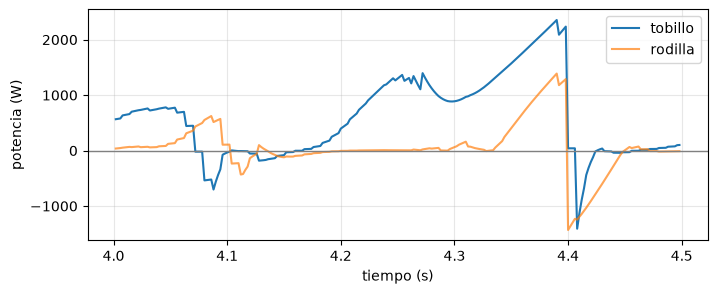

In [21]:
t = np.arange(len(potencias)) * paso_h
tramo = (t > 4) & (t < 4.5)
plt.figure(figsize=(8, 3))
plt.plot(t[tramo], potencias[tramo, 2], label="tobillo")
plt.plot(t[tramo], potencias[tramo, 1], label="rodilla", alpha=0.7)
plt.axhline(0, color="gray", lw=1)
plt.xlabel("tiempo (s)")
plt.ylabel("potencia (W)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

(`(t > 4) & (t < 4.5)` es una "máscara" de NumPy que elige los instantes entre 4 y 4,5 s, NB27.) Cada salto es un
pico enorme de potencia **positiva** del tobillo (miles de vatios durante unas centésimas: el empujón) y, alrededor,
tramos **negativos** de la rodilla (el aterrizaje, frenando). Así trabajan también tus piernas al correr.

### Tus retos

**Reto 1.** En el Paso 2, prueba un amortiguador **muy** fuerte (c = 5). ¿Llega el palo al suelo? ¿Cuánta energía se
come el amortiguador? (Pon un límite de tiempo al bucle: `and datos_p.time < 20`.)

**Reto 2.** En el Paso 3, apaga la amortiguación (`damping="0"`) y simula solo **2 segundos**. ¿Se sigue cumpliendo
el balance trabajo del motor = energía ganada?

**Reto 3.** En el Paso 4, calcula el castigo de control que pagó Hopper en el episodio (0,001 × suma de acciones² en
cada decisión, NB35). Compáralo con la energía que dieron sus motores. ¿Era un buen castigo para ahorrar batería?

<details>
<summary>▶ Solución Reto 1</summary>

```python
modelo_p, datos_p = taller.cargar(palo(amortiguador=5))
datos_p.qpos[0] = theta0
mujoco.mj_forward(modelo_p, datos_p)
inicial, disipada = datos_p.energy.sum(), 0.0
while datos_p.qpos[0] < math.pi / 2 and datos_p.time < 20:
    disipada += 5 * datos_p.qvel[0] ** 2 * modelo_p.opt.timestep
    mujoco.mj_step(modelo_p, datos_p)
print(round(datos_p.time, 2), round(datos_p.energy.sum(), 3), round(disipada, 3))
```

Llega, pero tarda mucho más: unos **3,0 s**, y llega despacio: el amortiguador se come **6,58** de los 7,35 J, y
solo quedan 0,76 J de cinética al tocar el suelo (1,4 rad/s, en vez de los 4,4 sin freno). Es lo que hace un buen
"aterrizaje": convertir en calor, poco a poco, la energía de la caída.
</details>

<details>
<summary>▶ Solución Reto 2</summary>

Cambia `damping="0.5"` por `damping="0"` en `BRAZO` y `range(15000)` por `range(2000)`. Sale trabajo del motor
**3,049 J** y energía ganada **3,054 J** (la diferencia, 5 milésimas, es el error de los pasitos), y disipada = 0. Sin
amortiguador, el brazo se columpia sin parar entre 0° y unos 65°, y la energía va y viene entre el motor, la altura y
la velocidad, pero el balance **siempre** cuadra.
</details>

<details>
<summary>▶ Solución Reto 3</summary>

Hay que guardar las acciones en el bucle del Paso 4:

```python
modelo_h, datos_h = taller.cargar("hopper")
castigo = 0.0
for decision in range(1000):
    accion = np.clip(decidir(datos_h), -1, 1)
    castigo += 0.001 * np.sum(accion ** 2)
    datos_h.ctrl[:] = accion
    for k in range(4):
        mujoco.mj_step(modelo_h, datos_h)
print(round(castigo, 2))
```

Sale **0,75 puntos** en todo el episodio (en el NB35, ejercicio E4, ya lo intuimos: unos 0,8). Frente a los
~3.500 puntos de nota y los más de 5.600 J que dieron sus motores, es un castigo de risa: a Hopper ahorrar energía no
le importaba nada. Si quisiéramos un saltarín eficiente, habría que poner ese peso mucho más alto (y reentrenar).
</details>

### Qué has aprendido de MuJoCo hoy

- **`<flag energy="enable"/>`** dentro de `<option>` enciende el contador; **`datos.energy`** = [potencial, cinética].
- El **balance de energía** como herramienta: energía final + disipada = inicial (+ trabajo de los motores).
- **`datos.actuator_force`** × **`datos.actuator_velocity`** = la **potencia** de cada motor (positiva: da;
  negativa: frena).
- Hacer andar a una política de SB3 en un MuJoCo "desnudo": construir la **observación** a mano y repetir cada
  decisión varios pasitos (lo que hace Gymnasium por dentro).
- El **coste de transporte** de un robot de verdad, medido.

En la práctica del NB39 vas a construir en MuJoCo el **péndulo invertido lineal**, con una pierna telescópica de
verdad, darle un empujón y pisar en su **punto de captura**.


## 12 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En la práctica has medido julios y vatios de verdad en MuJoCo. En el **NB39** vuelve el equilibrio, ahora en movimiento: el **péndulo invertido lineal**, el **punto de captura** y el **ZMP**. Allí aparecerá una "**energía orbital**" que se conserva: no es exactamente la energía de hoy, pero es su pariente, y la usarás con el mismo truco que en el apartado 4: si algo no cambia, el principio te dice el final.
